# 多元微积分可视化：等高线、梯度与二次曲面

这个 notebook 用 Python 图形展示二元函数的三个基本概念：

1. 等高线如何对应三维曲面的水平切片。
2. 梯度如何指向局部最速上升方向，并且垂直于等高线。
3. 二次曲面如何由二次型矩阵的特征值符号分类。

主要图形使用 Plotly 生成交互式 3D 图，二维等高线和梯度向量场使用 Matplotlib。

## 0. 环境检查与导入

如果下面单元提示缺少依赖，请在终端运行：

```bash
python3 -m pip install -r requirements.txt
jupyter lab multivariable_calculus_visuals.ipynb
```

In [1]:
# 导入 importlib.util，用来在真正 import 前检查某个包是否已安装。
import importlib.util
# 导入 os，用来设置 Matplotlib 缓存目录等运行环境变量。
import os
# 导入 sys，用来打印当前 Python 版本。
import sys

# 指定 Matplotlib 配置缓存目录，避免某些 Jupyter/沙盒环境下默认目录不可写。
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

# 列出本 notebook 运行所需的 Python 包。
required_packages = ["numpy", "matplotlib", "plotly", "ipywidgets"]
# 逐个检查依赖是否可被 Python 找到，找不到的包会进入 missing_packages。
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]

# 打印当前 Python 版本，便于确认 notebook 使用的是预期解释器。
print(f"Python: {sys.version.split()[0]}")
# 如果有缺失依赖，就给出安装命令并停止执行，避免后续报更难读的错误。
if missing_packages:
    # 把缺少的依赖包名合并成一行中文提示。
    print("缺少依赖：" + ", ".join(missing_packages))
    # 提示用户使用当前目录的 requirements.txt 安装依赖。
    print("请先运行：python3 -m pip install -r requirements.txt")
    # 主动抛出异常，阻止 notebook 继续运行到绘图单元。
    raise ModuleNotFoundError("Missing packages: " + ", ".join(missing_packages))

# 导入 NumPy，并约定简写为 np，用于生成网格、计算数组和做线性代数。
import numpy as np
# 导入 Matplotlib 的 pyplot，并约定简写为 plt，用于二维等高线和梯度箭头图。
import matplotlib.pyplot as plt
# 导入 Matplotlib 字体管理器，用于检测系统中是否有可显示中文的字体。
from matplotlib import font_manager
# 导入 Plotly 的底层图形对象接口，并约定简写为 go，用于三维曲面和交互图。
import plotly.graph_objects as go
# 导入 Plotly 子图工具，用于把三维曲面和二维等高线并排显示。
from plotly.subplots import make_subplots
# 导入 ipywidgets 的滑块和 interact，用于二次曲面的交互实验。
from ipywidgets import FloatSlider, interact

# 按优先级列出常见中文字体名称；不同系统可用字体名称可能不同。
chinese_font_candidates = [
    # 简体中文 Noto CJK 字体，Linux/WSL 上常见。
    "Noto Sans CJK SC",
    # 日文 Noto CJK 字体也覆盖常用汉字，本机通常能检测到这个名称。
    "Noto Sans CJK JP",
    # 繁体中文 Noto CJK 字体，也可显示大部分汉字。
    "Noto Sans CJK TC",
    # 思源黑体的常见字体名称。
    "Source Han Sans SC",
    # 思源黑体在部分系统里的另一个名称。
    "Source Han Sans CN",
    # 文泉驿微米黑，部分 Linux 发行版可用。
    "WenQuanYi Micro Hei",
    # 微软雅黑，Windows 系统常见。
    "Microsoft YaHei",
    # 黑体，Windows 或中文环境中常见。
    "SimHei",
    # 覆盖面较广的 Unicode 字体，部分 macOS/旧环境可用。
    "Arial Unicode MS",
]
# 从 Matplotlib 字体缓存中取出所有已识别字体的名称。
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
# 在候选列表中选择第一个已经被 Matplotlib 识别到的中文字体。
matplotlib_chinese_font = next((name for name in chinese_font_candidates if name in available_font_names), None)

# 设置 Matplotlib 默认图像尺寸，后续未显式指定大小的二维图会使用这个尺寸。
plt.rcParams["figure.figsize"] = (7, 5)
# 设置默认字体族为 sans-serif，便于按下面的 sans-serif 列表查找中文字体。
plt.rcParams["font.family"] = "sans-serif"
# 如果检测到可用中文字体，就把它放在 Matplotlib 字体回退列表最前面。
if matplotlib_chinese_font:
    # DejaVu Sans 作为后备字体，用来补充英文、数字和数学符号。
    plt.rcParams["font.sans-serif"] = [matplotlib_chinese_font, "DejaVu Sans"]
# 如果没有检测到中文字体，仍然写入候选列表，让用户安装字体后重启 kernel 即可生效。
else:
    # 这些名称现在可能不可用；安装字体后，Matplotlib 重建字体缓存即可识别。
    plt.rcParams["font.sans-serif"] = chinese_font_candidates + ["DejaVu Sans"]
# 让坐标轴负号使用普通减号，避免中文字体环境下负号显示为方框。
plt.rcParams["axes.unicode_minus"] = False

# 打印依赖检查结果，说明主要库已经成功导入。
print("依赖检查通过。")
# 如果找到中文字体，就告诉用户当前使用哪一个。
if matplotlib_chinese_font:
    print("Matplotlib 中文字体：" + matplotlib_chinese_font)
# 如果没找到中文字体，给出可执行的修复方案。
else:
    print("未检测到 Matplotlib 可用中文字体，二维图中的中文可能显示为方框。")
    print("解决方案 Linux/WSL: sudo apt update && sudo apt install fonts-noto-cjk")
    print("安装后重启 Jupyter kernel；如仍无效，可删除 Matplotlib 字体缓存：rm -rf ~/.cache/matplotlib")


Python: 3.11.15
依赖检查通过。
Matplotlib 中文字体：Noto Sans CJK JP


## 0.1 绘图环境与命令速查

本 notebook 的绘图环境由 JupyterLab、NumPy、Matplotlib、Plotly 和 ipywidgets 组成。运行顺序建议是：先运行第 0 节导入单元，再从上到下运行示例单元。

- `numpy` 用来生成网格和做向量化计算：`np.linspace` 生成坐标轴，`np.meshgrid` 生成二维网格，函数 `f(X, Y)` 一次性计算整张图上的函数值。
- `matplotlib.pyplot` 用来画二维静态图：`plt.subplots` 创建画布，`ax.contour` 画等高线，`ax.clabel` 标注等高线数值，`ax.quiver` 画梯度箭头，`fig.colorbar` 加颜色说明，`ax.set_aspect("equal")` 保持横纵比例一致。
- `plotly.graph_objects` 用来画可旋转的三维图：`go.Surface` 画曲面，`go.Contour` 画二维等高线，`fig.add_trace` 把图层加入画布，`fig.update_layout` 和 `fig.update_scenes` 控制标题、大小、坐标轴和相机角度。
- `ipywidgets.interact` 用来做滑块交互：把滑块值传给函数，然后重新绘制对应的二次曲面。

后续示例主要调用已经封装好的 `plot_surface_and_contours`、`plot_contour_with_gradient` 和 `plot_quadratic_surface`。如果只想改函数图像，通常只需要改 `def f(x, y): ...` 或二次型矩阵 `A`。

二维图中的中文由第 0 节导入单元自动配置。当前机器会优先使用 Noto/思源/微软雅黑/黑体等中文字体，并设置 `axes.unicode_minus=False`，避免负号显示成方框。若导入单元提示没有检测到中文字体，在 Linux/WSL 上运行 `sudo apt update && sudo apt install fonts-noto-cjk`，然后重启 Jupyter kernel；如果仍无效，再运行 `rm -rf ~/.cache/matplotlib` 删除字体缓存后重启。

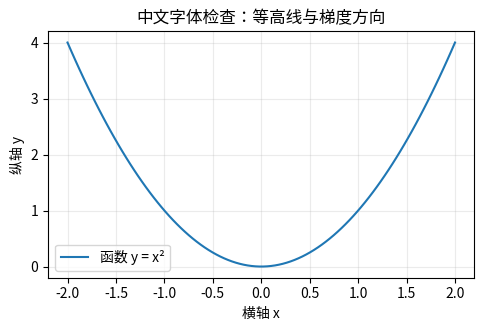

In [2]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
x_demo = np.linspace(-2, 2, 100)
ax.plot(x_demo, x_demo**2, label="函数 y = x²")
ax.set_title("中文字体检查：等高线与梯度方向")
ax.set_xlabel("横轴 x")
ax.set_ylabel("纵轴 y")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 1. 通用绘图工具

下面的函数会被后续所有示例复用。

In [3]:
# 定义一个生成二维网格的工具函数；xlim/ylim 控制范围，n 控制每个方向采样点数。
def make_grid(xlim=(-3, 3), ylim=(-3, 3), n=121):
    # 用函数文档字符串说明返回值用途，Jupyter 中可通过 help(make_grid) 查看。
    """生成二维网格。"""
    # 在 x 方向生成 n 个等距点。
    x = np.linspace(xlim[0], xlim[1], n)
    # 在 y 方向生成 n 个等距点。
    y = np.linspace(ylim[0], ylim[1], n)
    # 把一维 x/y 坐标扩展成二维网格坐标矩阵。
    X, Y = np.meshgrid(x, y)
    # 同时返回一维坐标轴和二维网格，便于二维/三维绘图复用。
    return x, y, X, Y


# 定义一个在网格上计算 f 函数值的工具函数。
def evaluate_on_grid(f, X, Y):
    # 用函数文档字符串说明输入函数 f 必须支持 NumPy 数组。
    """在网格上计算函数值，并转为浮点数组。"""
    # 对整张网格一次性计算 Z=f(X,Y)，并转成浮点数组。
    Z = np.asarray(f(X, Y), dtype=float)
    # 检查输出形状是否和输入网格一致，防止函数写法不支持向量化。
    if Z.shape != X.shape:
        # 如果形状不一致，给出面向学习者的错误说明。
        raise ValueError("函数必须能接受 numpy 数组，并返回与网格同形状的数组。")
    # 返回可直接用于绘图的 Z 值矩阵。
    return Z


# 定义三维曲面和二维等高线并排显示的绘图函数。
def plot_surface_and_contours(f, xlim=(-3, 3), ylim=(-3, 3), n=121, title=""):
    # 用函数文档字符串概括函数用途。
    """并排展示二元函数的三维曲面和二维等高线。"""
    # 生成绘图所需的一维坐标轴和二维网格。
    x, y, X, Y = make_grid(xlim, ylim, n)
    # 在二维网格上计算函数值 Z=f(X,Y)。
    Z = evaluate_on_grid(f, X, Y)

    # 创建 1 行 2 列的 Plotly 子图，左边放三维曲面，右边放二维等高线。
    fig = make_subplots(
        # 子图总行数。
        rows=1,
        # 子图总列数。
        cols=2,
        # 指定第一个子图是 surface 类型，第二个子图是 contour 类型。
        specs=[[{"type": "surface"}, {"type": "contour"}]],
        # 设置两个子图的标题。
        subplot_titles=("三维曲面 z = f(x, y)", "俯视图：等高线 f(x, y) = c"),
        # 设置左右子图宽度比例，让三维图稍宽一些。
        column_widths=[0.55, 0.45],
    )

    # 向左侧子图添加三维曲面图层。
    fig.add_trace(
        # go.Surface 用 X、Y、Z 三个矩阵绘制曲面。
        go.Surface(
            # 曲面的 x 坐标矩阵。
            x=X,
            # 曲面的 y 坐标矩阵。
            y=Y,
            # 曲面的 z 坐标矩阵，即函数值。
            z=Z,
            # 使用 Viridis 色带表示函数值高低。
            colorscale="Viridis",
            # 设置颜色条标题和长度。
            colorbar={"title": "f(x,y)", "len": 0.72},
            # 在三维曲面上显示 z 方向等高线，帮助对应右侧俯视图。
            contours={"z": {"show": True, "usecolormap": True, "highlightcolor": "white"}},
        ),
        # 把曲面放在第 1 行。
        row=1,
        # 把曲面放在第 1 列。
        col=1,
    )
    # 向右侧子图添加二维等高线图层。
    fig.add_trace(
        # go.Contour 用一维 x/y 轴和二维 Z 值绘制等高线。
        go.Contour(
            # 等高线图的 x 坐标轴。
            x=x,
            # 等高线图的 y 坐标轴。
            y=y,
            # 等高线图的函数值矩阵。
            z=Z,
            # 使用与三维曲面一致的色带。
            colorscale="Viridis",
            # 在等高线上显示数值标签，并设置标签字号。
            contours={"showlabels": True, "labelfont": {"size": 10}},
            # 右侧图不单独显示颜色条，避免和左侧颜色条重复。
            showscale=False,
        ),
        # 把等高线放在第 1 行。
        row=1,
        # 把等高线放在第 2 列。
        col=2,
    )

    # 设置整体标题、画布尺寸和边距。
    fig.update_layout(title=title, width=1050, height=560, margin={"l": 20, "r": 20, "t": 80, "b": 20})
    # 设置三维场景的坐标轴标题、比例和初始观察角度。
    fig.update_scenes(
        # 三维图 x 轴标题。
        xaxis_title="x",
        # 三维图 y 轴标题。
        yaxis_title="y",
        # 三维图 z 轴标题。
        zaxis_title="z",
        # 使用近似立方比例，避免某个方向被视觉压扁。
        aspectmode="cube",
        # 设置相机初始位置，打开图时能同时看到曲面高度和底面形状。
        camera={"eye": {"x": 1.45, "y": 1.45, "z": 0.95}},
    )
    # 设置右侧二维等高线的 x 轴标题。
    fig.update_xaxes(title_text="x", row=1, col=2)
    # 设置右侧二维等高线的 y 轴标题，并锁定横纵比例为 1:1。
    fig.update_yaxes(title_text="y", row=1, col=2, scaleanchor="x", scaleratio=1)
    # 在 Jupyter 中显示 Plotly 交互图。
    fig.show()


# 定义在等高线上叠加梯度向量场的二维绘图函数。
def plot_contour_with_gradient(f, grad_f, xlim=(-3, 3), ylim=(-3, 3), n=121, density=17, points=None, title=""):
    # 用函数文档字符串说明箭头经过归一化，颜色表示梯度长度。
    """在等高线上叠加归一化梯度方向。颜色表示梯度长度。"""
    # 生成较密的网格，用于绘制平滑等高线。
    _, _, X, Y = make_grid(xlim, ylim, n)
    # 在密网格上计算函数值。
    Z = evaluate_on_grid(f, X, Y)

    # 生成较稀疏的网格，用于放置梯度箭头，避免箭头太密。
    _, _, QX, QY = make_grid(xlim, ylim, density)
    # 在箭头网格上计算梯度的两个分量。
    GX, GY = grad_f(QX, QY)
    # 把 x 方向梯度分量转成浮点数组。
    GX = np.asarray(GX, dtype=float)
    # 把 y 方向梯度分量转成浮点数组。
    GY = np.asarray(GY, dtype=float)
    # 计算梯度长度 |∇f|，也就是箭头颜色所表示的量。
    speed = np.hypot(GX, GY)
    # 把 x 方向分量归一化；梯度接近 0 的位置用 0 避免除零。
    UX = np.divide(GX, speed, out=np.zeros_like(GX), where=speed > 1e-12)
    # 把 y 方向分量归一化；梯度接近 0 的位置用 0 避免除零。
    UY = np.divide(GY, speed, out=np.zeros_like(GY), where=speed > 1e-12)

    # 创建 Matplotlib 画布和坐标轴。
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    # 绘制函数 f 的等高线。
    contour = ax.contour(X, Y, Z, levels=16, cmap="viridis")
    # 在等高线上标出对应的函数值。
    ax.clabel(contour, inline=True, fontsize=8)
    # 绘制梯度方向箭头，并用颜色表示梯度长度。
    quiver = ax.quiver(QX, QY, UX, UY, speed, cmap="magma", pivot="mid", scale=28)
    # 给梯度长度颜色映射添加颜色条。
    cbar = fig.colorbar(quiver, ax=ax, shrink=0.82)
    # 设置颜色条标签。
    cbar.set_label("梯度长度 |∇f|")

    # 如果传入了观察点，就把这些点标在图上。
    if points:
        # 把点列表拆成 x 坐标序列和 y 坐标序列。
        px, py = zip(*points)
        # 用黑点标出指定观察点。
        ax.scatter(px, py, s=45, c="black", zorder=4, label="选定点")
        # 逐个给观察点添加坐标文字。
        for point in points:
            # 在点旁边标注坐标，xytext 用来让文字略微偏离点本身。
            ax.annotate(f"({point[0]:.1f}, {point[1]:.1f})", point, xytext=(6, 6), textcoords="offset points")

    # 设置二维图标题。
    ax.set_title(title)
    # 设置 x 轴标签。
    ax.set_xlabel("x")
    # 设置 y 轴标签。
    ax.set_ylabel("y")
    # 保持 x/y 单位长度一致，让圆形等高线不会被拉伸成椭圆。
    ax.set_aspect("equal", adjustable="box")
    # 添加浅色网格，方便读坐标。
    ax.grid(alpha=0.2)
    # 如果图上有观察点，就显示图例。
    if points:
        # 把图例放到右上角。
        ax.legend(loc="upper right")
    # 在 Jupyter 中显示 Matplotlib 图。
    plt.show()


# 定义在单点比较梯度方向和等高线切向方向的绘图函数。
def plot_gradient_and_tangent(f, grad_f, point, xlim=(-3, 3), ylim=(-3, 3), title=""):
    # 用函数文档字符串说明这个函数的教学用途。
    """在一点画出梯度方向和等高线切向方向。"""
    # 生成更密的网格，使局部等高线更平滑。
    _, _, X, Y = make_grid(xlim, ylim, 161)
    # 在网格上计算函数值，用于绘制等高线背景。
    Z = evaluate_on_grid(f, X, Y)
    # 拆出观察点坐标。
    x0, y0 = point
    # 在观察点计算梯度分量；float 转换保证输入是普通数值。
    gx, gy = grad_f(float(x0), float(y0))
    # 把梯度分量组成二维向量。
    gradient = np.array([gx, gy], dtype=float)
    # 对梯度 (f_x, f_y) 旋转 90 度，得到一个等高线切向量 (-f_y, f_x)。
    tangent = np.array([-gy, gx], dtype=float)
    # 计算梯度向量长度，用于归一化。
    grad_norm = np.linalg.norm(gradient)
    # 计算切向量长度，用于归一化。
    tan_norm = np.linalg.norm(tangent)

    # 如果梯度接近零，该点没有明确的最速上升方向。
    if grad_norm < 1e-12:
        # 主动停止并提示用户换一个非临界点观察。
        raise ValueError("该点的梯度接近零，无法展示明确的法向方向。")

    # 把梯度向量变成单位向量，便于在图中显示方向。
    gradient_unit = gradient / grad_norm
    # 把切向量变成单位向量，便于和梯度方向比较。
    tangent_unit = tangent / tan_norm
    # 计算梯度和切向量的点积，理论上应为 0。
    dot_product = float(np.dot(gradient, tangent))

    # 创建 Matplotlib 画布和坐标轴。
    fig, ax = plt.subplots(figsize=(7.2, 6.2))
    # 绘制等高线背景。
    contour = ax.contour(X, Y, Z, levels=18, cmap="viridis")
    # 给等高线添加数值标签。
    ax.clabel(contour, inline=True, fontsize=8)
    # 用黑点标出观察点。
    ax.scatter([x0], [y0], c="black", s=50, zorder=5)
    # 用红色箭头画梯度方向。
    ax.quiver([x0], [y0], [gradient_unit[0]], [gradient_unit[1]], color="crimson", scale=4, width=0.008, label="梯度方向 ∇f")
    # 用蓝色箭头画等高线切向方向。
    ax.quiver([x0], [y0], [tangent_unit[0]], [tangent_unit[1]], color="royalblue", scale=4, width=0.008, label="等高线切向")
    # 设置图标题。
    ax.set_title(title)
    # 设置 x 轴标签。
    ax.set_xlabel("x")
    # 设置 y 轴标签。
    ax.set_ylabel("y")
    # 保持横纵坐标比例一致。
    ax.set_aspect("equal", adjustable="box")
    # 添加浅色网格。
    ax.grid(alpha=0.2)
    # 显示红蓝箭头的图例。
    ax.legend(loc="upper right")
    # 在 Jupyter 中显示图形。
    plt.show()
    # 打印观察点处的梯度数值。
    print(f"点 ({x0:.2f}, {y0:.2f}) 处的梯度为 ({gx:.3f}, {gy:.3f})。")
    # 打印切向量和点积，验证梯度垂直于等高线切向。
    print(f"取切向量 (-f_y, f_x) = ({tangent[0]:.3f}, {tangent[1]:.3f})，点积 ∇f · t = {dot_product:.3g}。")


## 2. 等高线：三维曲面的水平切片

对于二元函数 $z=f(x,y)$，等高线 $f(x,y)=c$ 是三维曲面被水平平面 $z=c$ 切出来后投影到 $xy$ 平面的曲线。

In [4]:
def bowl(x, y):
    return x**2 + y**2


plot_surface_and_contours(bowl, xlim=(-3, 3), ylim=(-3, 3), title="例 1：f(x, y) = x² + y²")

观察：圆形等高线越往外，函数值越大；三维图中对应的是向上打开的碗形曲面。观察等高线和水平集（level set）的直观。 

In [5]:
def saddle(x, y):
    return x**2 - y**2


plot_surface_and_contours(saddle, xlim=(-3, 3), ylim=(-3, 3), title="例 2：f(x, y) = x² - y²")

观察：鞍面在 $x$ 方向上升、在 $y$ 方向下降；等高线变成双曲线。

In [6]:
def wave(x, y):
    return np.sin(x) * np.cos(y)


plot_surface_and_contours(wave, xlim=(-2 * np.pi, 2 * np.pi), ylim=(-2 * np.pi, 2 * np.pi), title="例 3：f(x, y) = sin(x)cos(y)")

## 3. 梯度：最速上升方向

梯度记作

$$\nabla f(x,y)=\left(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y}\right).$$

在几何上，梯度方向是函数值局部增加最快的方向。对于非临界点，梯度还垂直于经过该点的等高线。

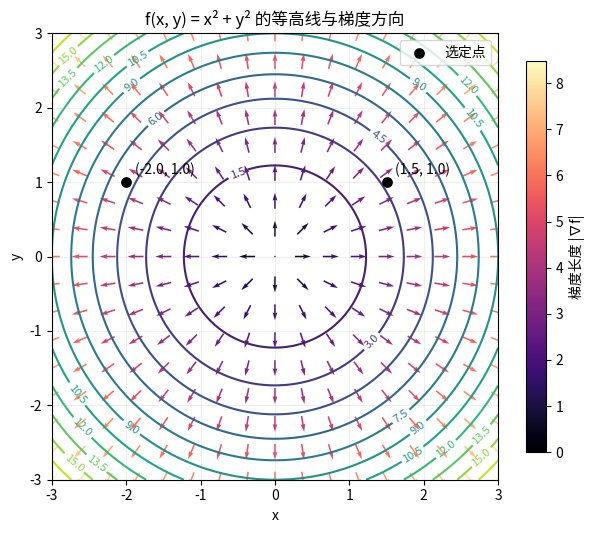

In [7]:
def grad_bowl(x, y):
    return 2 * x, 2 * y

# 等高线和梯度场叠加
plot_contour_with_gradient(
    bowl,
    grad_bowl,
    xlim=(-3, 3),
    ylim=(-3, 3),
    points=[(1.5, 1.0), (-2.0, 1.0)],
    title="f(x, y) = x² + y² 的等高线与梯度方向",
)

观察：箭头从原点向外，说明离原点越远函数值越大；箭头方向和圆形等高线垂直。箭头长度被归一化，颜色代表了模长。

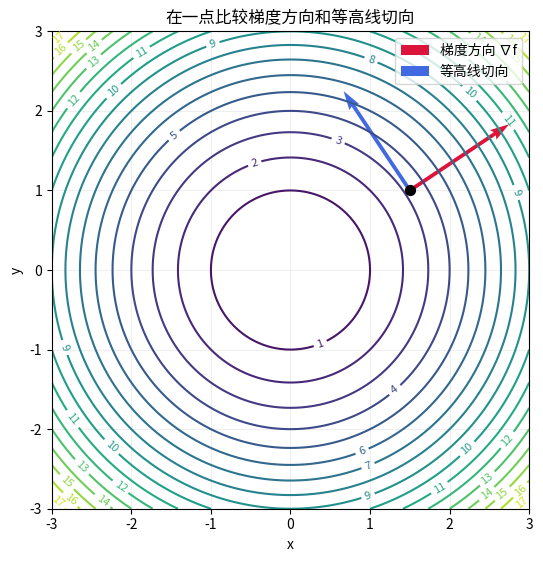

点 (1.50, 1.00) 处的梯度为 (3.000, 2.000)。
取切向量 (-f_y, f_x) = (-2.000, 3.000)，点积 ∇f · t = 0。


In [8]:
plot_gradient_and_tangent(
    bowl,
    grad_bowl,
    point=(1.5, 1.0),
    xlim=(-3, 3),
    ylim=(-3, 3),
    title="在一点比较梯度方向和等高线切向",
)

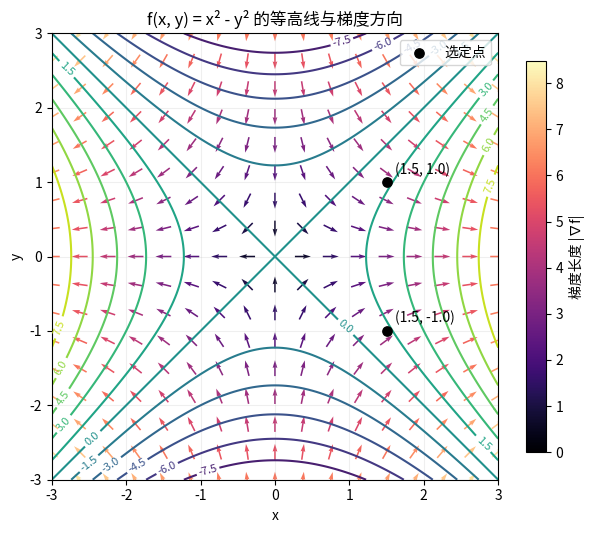

In [9]:
def grad_saddle(x, y):
    return 2 * x, -2 * y


plot_contour_with_gradient(
    saddle,
    grad_saddle,
    xlim=(-3, 3),
    ylim=(-3, 3),
    points=[(1.5, 1.0), (1.5, -1.0)],
    title="f(x, y) = x² - y² 的等高线与梯度方向",
)

## 4. 二次曲面：用二次型矩阵分类

本节考虑形如

$$f(x,y)=\begin{bmatrix}x & y\end{bmatrix}A\begin{bmatrix}x\\y\end{bmatrix}+b^T\begin{bmatrix}x\\y\end{bmatrix}+c$$

的函数。这里 $A$ 是 $2\times2$ 对称矩阵。矩阵 $A$ 的特征值符号决定了曲面的主要形状。线性项 $b$ 主要改变顶点位置，不改变二次项决定的开口类型。

In [10]:
# 将矩阵 A 对称化
def symmetrize(A):
    A = np.asarray(A, dtype=float)
    if A.shape != (2, 2):
        raise ValueError("A 必须是 2x2 矩阵。")
    return 0.5 * (A + A.T)

# 区分二次曲面类型
def classify_quadratic(A, tol=1e-10):
    """按二次型矩阵特征值符号给出二次曲面分类。"""
    A = symmetrize(A)
    eigenvalues = np.linalg.eigvalsh(A)
    positive = eigenvalues > tol
    negative = eigenvalues < -tol
    zero = np.abs(eigenvalues) <= tol

    if positive.all():
        classification = "正定：椭圆抛物面，开口向上"
    elif negative.all():
        classification = "负定：倒椭圆抛物面，开口向下"
    elif positive.any() and negative.any():
        classification = "不定：双曲抛物面，也叫鞍面"
    elif positive.any() and zero.any():
        classification = "半正定：抛物柱面或退化椭圆抛物面"
    elif negative.any() and zero.any():
        classification = "半负定：倒抛物柱面或退化椭圆抛物面"
    else:
        classification = "零二次项：平面或常数面"

    return {"A": A, "eigenvalues": eigenvalues, "classification": classification}


# 计算二次曲面
def quadratic_function(A, b=(0, 0), c=0):
    """返回 f(x,y)= [x,y]A[x,y]^T + b^T[x,y] + c。"""
    A = symmetrize(A)
    b = np.asarray(b, dtype=float)
    if b.shape != (2,):
        raise ValueError("b 必须是长度为 2 的向量。")

    def f(x, y):
        return A[0, 0] * x**2 + 2 * A[0, 1] * x * y + A[1, 1] * y**2 + b[0] * x + b[1] * y + c

    return f

# 绘制二次曲面
def plot_quadratic_surface(A, b=(0, 0), c=0, xlim=(-3, 3), ylim=(-3, 3), n=121, title=None):
    info = classify_quadratic(A)
    f = quadratic_function(info["A"], b=b, c=c)
    eigen_text = np.array2string(info["eigenvalues"], precision=3)
    display_title = title or info["classification"]
    print("A =")
    print(info["A"])
    print(f"特征值：{eigen_text}")
    print(f"分类：{info['classification']}")
    plot_surface_and_contours(f, xlim=xlim, ylim=ylim, n=n, title=display_title)
    return info

### 4.1 正定：椭圆抛物面

In [11]:
A_positive = np.array([[1, 0], [0, 1]])
plot_quadratic_surface(A_positive, title="正定矩阵：f(x, y) = x² + y²");

A =
[[1. 0.]
 [0. 1.]]
特征值：[1. 1.]
分类：正定：椭圆抛物面，开口向上


### 4.2 负定：倒椭圆抛物面

In [12]:
A_negative = np.array([[-1, 0], [0, -1]])
plot_quadratic_surface(A_negative, title="负定矩阵：f(x, y) = -x² - y²");

A =
[[-1.  0.]
 [ 0. -1.]]
特征值：[-1. -1.]
分类：负定：倒椭圆抛物面，开口向下


### 4.3 不定：双曲抛物面

In [13]:
A_indefinite = np.array([[1, 0], [0, -1]])
plot_quadratic_surface(A_indefinite, title="不定矩阵：f(x, y) = x² - y²");

A =
[[ 1.  0.]
 [ 0. -1.]]
特征值：[-1.  1.]
分类：不定：双曲抛物面，也叫鞍面


### 4.4 半正定：抛物柱面

In [14]:
A_semipositive = np.array([[1, 0], [0, 0]])
plot_quadratic_surface(A_semipositive, title="半正定矩阵：f(x, y) = x²");

A =
[[1. 0.]
 [0. 0.]]
特征值：[0. 1.]
分类：半正定：抛物柱面或退化椭圆抛物面


### 4.5 线性项：改变位置，不改变开口类型

函数 $x^2+y^2-2x+4y$ 可以配方为 $(x-1)^2+(y+2)^2-5$，所以它仍然是向上开的椭圆抛物面，只是顶点移动到 $(1,-2)$。

In [15]:
plot_quadratic_surface(
    A_positive,
    b=(-2, 4),
    c=0,
    xlim=(-3, 5),
    ylim=(-6, 2),
    title="含线性项：f(x, y) = x² + y² - 2x + 4y",
);

A =
[[1. 0.]
 [0. 1.]]
特征值：[1. 1.]
分类：正定：椭圆抛物面，开口向上


## 5. 交互实验：调节二次型矩阵

令

$$A=\begin{bmatrix}a & h\\h & d\end{bmatrix}.$$

拖动滑块观察特征值符号和曲面形状如何一起变化。

In [16]:
def explore_quadratic(a=1.0, h=0.0, d=1.0):
    A = np.array([[a, h], [h, d]], dtype=float)
    info = classify_quadratic(A)
    eigen_text = np.array2string(info["eigenvalues"], precision=3)
    print(f"A = [[{a:.2f}, {h:.2f}], [{h:.2f}, {d:.2f}]]")
    print(f"特征值：{eigen_text}")
    print(f"分类：{info['classification']}")
    f = quadratic_function(A)
    plot_surface_and_contours(f, xlim=(-3, 3), ylim=(-3, 3), n=81, title="交互式二次曲面")


interact(
    explore_quadratic,
    a=FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.25, description="a, 第一对角元"),
    h=FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.25, description="h, 非对角元"),
    d=FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.25, description="d, 第二对角元"),
);

interactive(children=(FloatSlider(value=1.0, description='a, 第一对角元', max=2.0, min=-2.0, step=0.25), FloatSlide…

## 6. 小练习

1. 把下面的 `f_student` 改成你自己的二元函数，观察曲面和等高线。
2. 把 `A_student` 改成不同矩阵，先预测分类，再运行代码验证。
3. 找一个梯度为零的点，并解释为什么该点附近的梯度箭头变短或消失。

In [17]:
def f_student(x, y):
    return np.exp(-0.25 * (x**2 + y**2)) * np.cos(2 * x) + 0.15 * y


plot_surface_and_contours(f_student, xlim=(-4, 4), ylim=(-4, 4), title="练习 1：自定义函数")